In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
df = pd.read_csv('patients_clean.csv')
df.head(10)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11552 entries, 0 to 11551
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URI                        11552 non-null  object 
 1   uri_user                   11552 non-null  object 
 2   created                    11552 non-null  object 
 3   update_uri_user            26 non-null     object 
 4   updated                    11552 non-null  object 
 5   model                      11324 non-null  float64
 6   ui                         0 non-null      float64
 7   complete                   11552 non-null  int64  
 8   DATE_SUBMIT                11552 non-null  object 
 9   marked                     11552 non-null  object 
 10  DATE_REPORT                7037 non-null   object 
 11  Owner                      1986 non-null   object 
 12  Owner_village              1991 non-null   object 
 13  REGION                     11547 non-null  obj

DATA PREPROCESSING

In [23]:

features = ['REGION', 'animal_alive', 'PEP_AVAILABLE', 'SEX', 'PEP_RECOMMENDED',
            'animal', 'bite_site', 'animal_environment', 'HEALTHY_ANIMAL_BEHAVIOURS', 'symptoms']
target = 'rabies_status'

df.dropna(subset=features + [target], inplace=True)  

encoder = LabelEncoder()
for col in features + [target]:
    df[col] = encoder.fit_transform(df[col])


X = df[features]
y = df[target]


x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



TRAINING OF THE MODEL

In [24]:

svm_model = SVC(kernel='rbf', C=1, gamma = 'scale', random_state=42)
svm_model.fit(x_train, y_train)

y_pred = svm_model.predict(x_test)


accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Model Accuracy: {accuracy:.2f}')
print(report)



Accuracy: 0.4074074074074074
Model Accuracy: 0.41
              precision    recall  f1-score   support

           0       0.48      0.48      0.48        50
           1       0.36      0.87      0.51        30
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        19
           4       0.00      0.00      0.00         1
           5       0.38      0.18      0.24        28

    accuracy                           0.41       135
   macro avg       0.20      0.25      0.21       135
weighted avg       0.34      0.41      0.34       135



c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

UNIQUE CLASSES OF THE LABEL(rabies_status)

In [9]:

unique_classes = df['rabies_status'].unique()
print("Unique Classes in 'rabies_status':", unique_classes)


Unique Classes in 'rabies_status': ['unknown' 'suspicious_for_rabies' 'sick_not_rabies' 'healthy'
 'suspicious_for_of_rabies' nan 'treatment']


VISUALIZING THEM INTO A HISTOGRAM

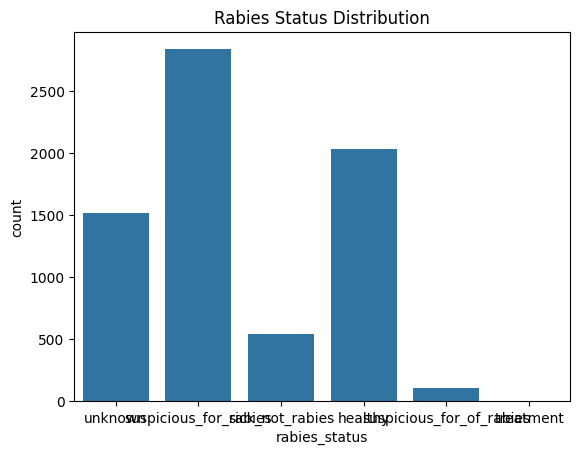

rabies_status
suspicious_for_rabies       2832
healthy                     2027
unknown                     1514
sick_not_rabies              542
suspicious_for_of_rabies     111
treatment                      3
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=df['rabies_status'])
plt.title("Rabies Status Distribution")
plt.show()

print(df['rabies_status'].value_counts())


REMOVING THE CLASSES[2,3,4] FROM THE LABEL{rabies_status}

In [36]:

# Encode the target variable if not already encoded
encoder = LabelEncoder()
df['rabies_status'] = encoder.fit_transform(df['rabies_status'])

# Filter dataset for rabies_status values 0, 1, and 5
df_filtered = df[df['rabies_status'].isin([0, 1, 5])]

# Handle missing values
df_filtered.dropna(subset=features + [target], inplace=True)

# Convert categorical features to numerical using Label Encoding
for col in features:
    df_filtered[col] = LabelEncoder().fit_transform(df_filtered[col])

# Split dataset
X = df_filtered[features]
y = df_filtered[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM model
svm_model = SVC(kernel='rbf', C=1.0,  gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))


Model Accuracy: 0.73
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.91      0.82        45
           1       0.66      0.72      0.69        32
           5       0.82      0.51      0.63        35

    accuracy                           0.73       112
   macro avg       0.74      0.71      0.71       112
weighted avg       0.74      0.73      0.72       112



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13516\2914158756.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.dropna(subset=features + [target], inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13516\2914158756.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[col] = LabelEncoder().fit_transform(df_filtered[col])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13516\2914158756.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

WHEN WE REMOVE FEATURES WITH INSIGNIFICANT WEIGHTS

In [42]:

features = ['animal_alive','animal', 'animal_environment', 'HEALTHY_ANIMAL_BEHAVIOURS', 'symptoms']
target = 'rabies_status'

df.dropna(subset=features + [target], inplace=True)  

encoder = LabelEncoder()
for col in features + [target]:
    df[col] = encoder.fit_transform(df[col])


X = df[features]
y = df[target]


x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:

# Encode the target variable if not already encoded
encoder = LabelEncoder()
df['rabies_status'] = encoder.fit_transform(df['rabies_status'])

# Filter dataset for rabies_status values 0, 1, and 5
df_filtered = df[df['rabies_status'].isin([0, 1, 5])]


df_filtered.dropna(subset=features + [target], inplace=True)

# Label Encoding
for col in features:
    df_filtered[col] = LabelEncoder().fit_transform(df_filtered[col])

# Split dataset
X = df_filtered[features]
y = df_filtered[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM model
svm_model = SVC(kernel='rbf', C=1.0,  gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

# the MODELS performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))


Model Accuracy: 0.84
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.96      0.92       210
           1       0.59      0.63      0.61        38
           5       0.79      0.31      0.45        35

    accuracy                           0.84       283
   macro avg       0.75      0.64      0.66       283
weighted avg       0.83      0.84      0.82       283



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13516\2914158756.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.dropna(subset=features + [target], inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13516\2914158756.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[col] = LabelEncoder().fit_transform(df_filtered[col])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13516\2914158756.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst